<a href="https://colab.research.google.com/github/PallavKhanal/MachineLearningProjects/blob/main/CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.19.0
Keras version: 3.10.0


In [ ]:
  (x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
#Examining the data
print(f"\nTraining data shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {x_test.shape}")
print(f"Test labels shape: {y_test.shape}")

#checking data types and ranges
print(f"\nData type of x_train: {x_train.dtype}")
print(f"Pixel value range: {x_train.min()} to {x_train.max()}" )
print(f"Label range: {y_train.min()} to {y_train.max()}")


Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)

Data type of x_train: uint8
Pixel value range: 0 to 255
Label range: 0 to 9


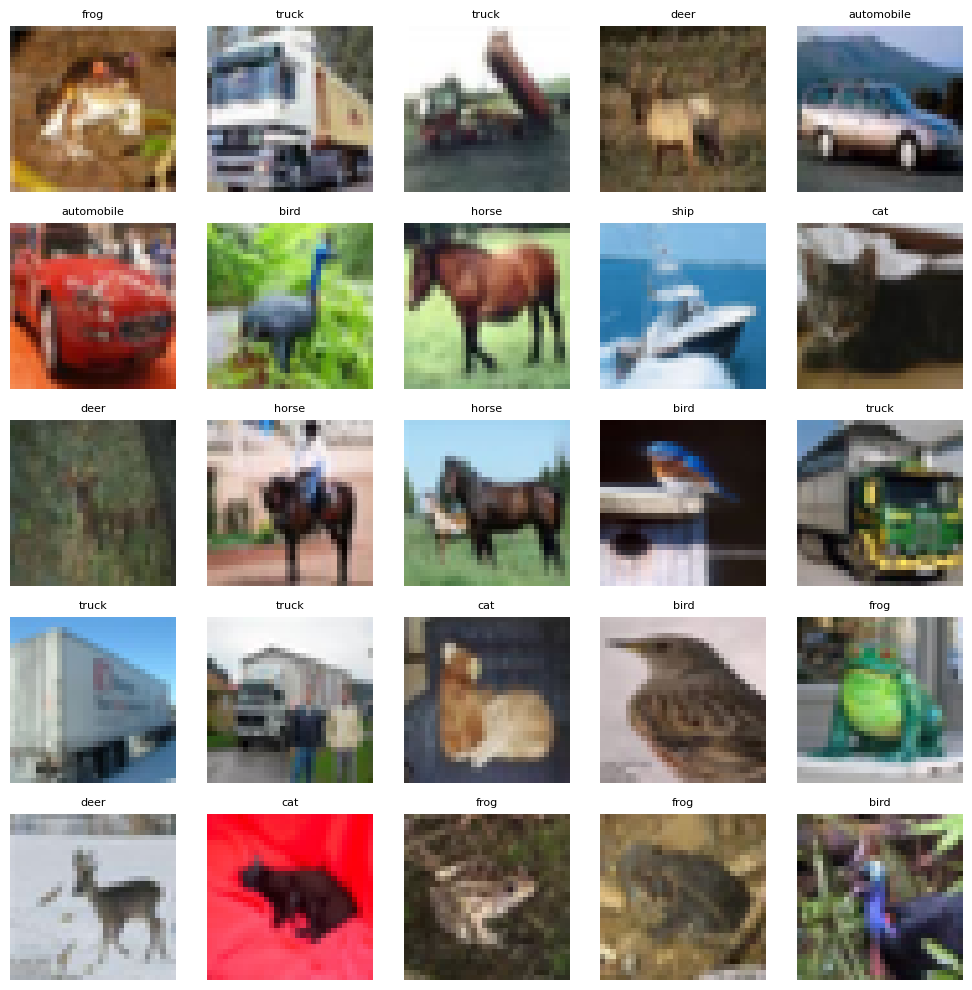

In [ ]:
#visualizing the data

#class names
class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog","horse","ship","truck"]

#plotting first 25 images
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]], fontsize = 8)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Normalize pixel values to be between 0 and 1

#Before Normalization
print("Before normalization:")
print(f"Sample pixel values: {x_train[0, 0, 0, :]}")


x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

#After Normalization
print("\nAfter normalization:")
print(f"Sample pixel values: {x_train[0, 0, 0, :]}")

#Benifits - NN works better with smallernumber, Prevents Gradient Explosion, speeds up training


Before normalization:
Sample pixel values: [59 62 63]

After normalization:
Sample pixel values: [0.23137255 0.24313726 0.24705882]


In [ ]:
y_train = y_train.flatten()
y_test = y_test.flatten()

print(f"\nLabel shape before: (50000, 1)")
print(f"Label shape after: {y_train.shape}")

#Converts shape from (50000,1 ) to (50000,) - removing the unnecessary dimension


Label shape before: (50000, 1)
Label shape after: (50000,)


In [ ]:
#Creating the Model


# Creating a sequential model (layers stack on top of each other)

model = models.Sequential(
    [
        # Data Augmentation
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),

        #creates a liner stack of layers - data flows from top to bottom
        #randomly flips and rotates the training data

        layers.Conv2D(
            32, 3, padding="same", activation="relu", input_shape=(32,32,3)
        ),


        #32 : number of filters, 3 : Kernal size(3*3 filter) padding same : adds padding so that the output is same size as the input
        # without padding , a 32*32 image with a 3*3 filter becomes 30*30 with padding same we add 1 pixel border keeping it 32*32
        #relu activation applies Relu after convolution, input shape (32, 32, 3) : First layer needs the input dimension


        # batch normalization : normalizes the outputs before passing to the new layer - speeds up training, makes training stable

        #maxpooling2D(2) : takes 2*2 windows, keeps only the max value, reduces 32*32 to 16*16

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),


        #second CNN: - uses structure as the first block - but uses 64 filters instead of 32 - reduces from 16*16 to 8*8

        #why more filters? early layers detect simple patterns(need fewer filters), later layers: detect complex patterns(need more filters)


        #CNN3
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        #even more filters , reduces from 8*8 to 4*4, now we have 4*4*128 = 2048 features


        #flatten converts 4*4*128 tensor into a flat list of 2048 numbers

        layers.Flatten(name="flatten"),
        layers.Dropout(0.5),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")

        #Dropout(0.5) - During training randomly sets 50% of input of 0, prevents overfitting
        #Dense(128, activation = "relu") fully connected layer with 128 neurons, cmobines learned features
        #Dense(10, activation = 'softmax') -- OutputLayer - 10 neurons(one per class), softmax converts to probablities, output sums to 1.0


  ]
)





In [ ]:
#compiling the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")
print("\nOptimizer: Adam")
print("Loss function: Sparse Categorical Crossentropy")
print("Metrics: Accuracy")

#optimizer adam - chooses how the weights are updated other option include gradient decent

#loss- sparse catrgorical crossentropy - sparse because labels are integers(0-9), catrgorical because we are classifying into categories, crossentropy is the mathematical formula

#metrices - accuracy - track accuracy during training

Model compiled successfully!

Optimizer: Adam
Loss function: Sparse Categorical Crossentropy
Metrics: Accuracy


In [ ]:
# Using a small subset for quick test
x_small = x_train[:1000]
y_small = y_train[:1000]

print(f"Training on {len(x_small)} images...")

history = model.fit(
    x_small, y_small,
    batch_size=32,
    epochs=5,
    validation_split=0.2,
    verbose=1
)

print("\nQuick training completed!")

Training on 1000 images...
Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 196ms/step - accuracy: 0.1763 - loss: 3.9690 - val_accuracy: 0.1300 - val_loss: 2.2840
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 191ms/step - accuracy: 0.3226 - loss: 1.9579 - val_accuracy: 0.1500 - val_loss: 3.0538
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 237ms/step - accuracy: 0.3147 - loss: 1.8042 - val_accuracy: 0.1300 - val_loss: 4.4442
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 211ms/step - accuracy: 0.3630 - loss: 1.7501 - val_accuracy: 0.1350 - val_loss: 6.0935
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 218ms/step - accuracy: 0.4137 - loss: 1.6528 - val_accuracy: 0.1750 - val_loss: 6.1353

Quick training completed!


In [ ]:
# Training the model
history = model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=10,
    validation_split=0.1
)


#this is where training happens, x_train, y_train Training images and labels
#batch size = 64 - trains 64 images at a time
#epochs = 30 - goes through entire dataset 30 times
#validation split 0.1 - holds out 10% of the data for validation. Used to monitor overfitting
#history - stores training metrices (loss, accuracy) at each epoch. Used for plotting.

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 402s 564ms/step - accuracy: 0.3460 - loss: 1.9624 - val_accuracy: 0.5474 - val_loss: 1.2545
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 393s 559ms/step - accuracy: 0.5326 - loss: 1.3040 - val_accuracy: 0.6148 - val_loss: 1.1013
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 391s 556ms/step - accuracy: 0.5960 - loss: 1.1466 - val_accuracy: 0.6094 - val_loss: 1.1267
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 441s 555ms/step - accuracy: 0.6260 - loss: 1.0628 - val_accuracy: 0.6184 - val_loss: 1.1147
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 388s 551ms/step - accuracy: 0.6434 - loss: 1.0171 - val_accuracy: 0.6882 - val_loss: 0.9163
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 385s 547ms/step - accuracy: 0.6591 - loss: 0.9624 - val_accuracy: 0.6810 - val_loss: 0.9400
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 385s 547ms/step - accuracy: 0.6707 - loss: 0.9364 - val_accuracy: 0.6124 - val_loss: 1.2042
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 445s 551ms/step - accuracy: 0.6855 -

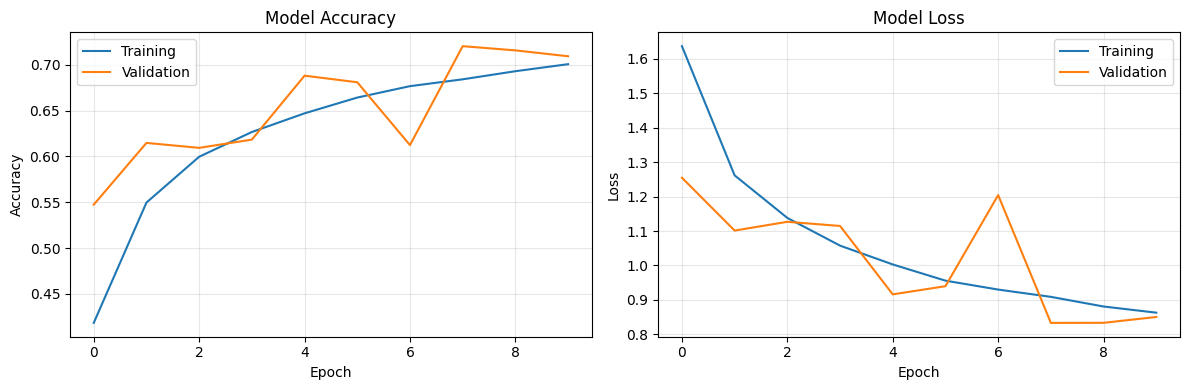

In [ ]:
# Plotting training history
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Evaluation

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

#test loss - how wrong the predictions were
#test accuracy - % of correct predictions

# Comparing with training/validation
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"\nComparison:")
print(f"Training Accuracy: {final_train_acc:.4f}")
print(f"Validation Accuracy: {final_val_acc:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")




313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.7150 - loss: 0.8356
Test Loss: 0.8353
Test Accuracy: 0.7118 (71.18%)

Comparison:
Training Accuracy: 0.7007
Validation Accuracy: 0.7094
Test Accuracy: 0.7118


In [ ]:
# make predictions
predictions = model.predict(x_test[:10])
predicted_classes = np.argmax(predictions, axis=1)

print("Predictions shape:", predictions.shape)
print("\nSample prediction (probabilities):")
print(predictions[0])
print(f"Sum of probabilities: {predictions[0].sum():.4f}")

# Get predicted classes
predicted_classes = np.argmax(predictions, axis=1)
true_classes = y_test[:10]

print("\nPredictions vs Truth:")
for i in range(10):
    pred_label = class_names[predicted_classes[i]]
    true_label = class_names[true_classes[i]]
    confidence = predictions[i][predicted_classes[i]]
    match = "✓" if predicted_classes[i] == true_classes[i] else "✗"
    print(f"{match} Predicted: {pred_label:12s} ({confidence:.2%}) | True: {true_label}")

#model.predict - gets predictions for images, returns probablity for each class
# np.argmax(predictions, axis=1) - finds the class with the highest probablity
# predictions shape - (10,10 ) - 10 images, 10 probablity each
# argmax - finds which of the 10 is highest
# axis - 1 - means finds max across columns

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
Predictions shape: (10, 10)

Sample prediction (probabilities):
[0.00447744 0.00244683 0.00806037 0.51977485 0.01070375 0.04015444
 0.07540322 0.00229753 0.3147278  0.0219537 ]
Sum of probabilities: 1.0000

Predictions vs Truth:
✓ Predicted: cat          (51.98%) | True: cat
✗ Predicted: automobile   (50.19%) | True: ship
✓ Predicted: ship         (60.78%) | True: ship
✓ Predicted: airplane     (72.94%) | True: airplane
✓ Predicted: frog         (62.64%) | True: frog
✓ Predicted: frog         (98.98%) | True: frog
✓ Predicted: automobile   (99.13%) | True: automobile
✓ Predicted: frog         (95.23%) | True: frog
✓ Predicted: cat          (42.72%) | True: cat
✓ Predicted: automobile   (96.98%) | True: automobile


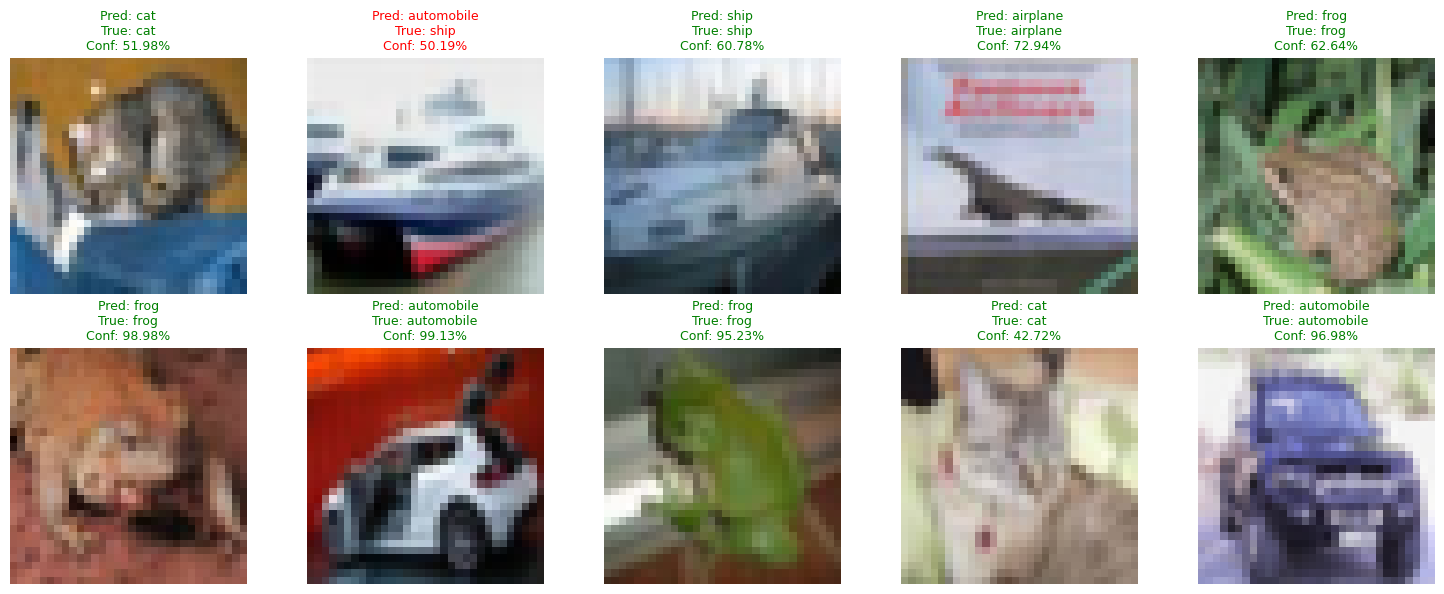

In [ ]:
# Visualizing correct and incorrect predictions
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i in range(10):
    ax = axes[i // 5, i % 5]

    # Show image
    ax.imshow(x_test[i])

    # Get prediction info
    pred_class = predicted_classes[i]
    true_class = true_classes[i]
    confidence = predictions[i][pred_class]

    # Color: green if correct, red if wrong
    color = 'green' if pred_class == true_class else 'red'

    # Title
    ax.set_title(f"Pred: {class_names[pred_class]}\n"
                 f"True: {class_names[true_class]}\n"
                 f"Conf: {confidence:.2%}",
                 color=color, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#saving the model
model.save("cifar10")

#what this does
#saves everything ie architecture weights and optimizer state
#later we can do loaded_model = keras.models.load_model('my_model.keras')

